#BoomBikes Bike Sharing Prediction

**Overview**

This project aims to predict daily bike rental demand using machine learning. The dataset includes weather conditions, seasonal information, and calendar-related features such as temperature, humidity, windspeed, working days, and holidays.
After cleaning and preparing the data, relevant features were selected and scaled to improve model performance. A Linear Regression model was then trained to understand how these factors influence the total rental count (cnt). The model was evaluated to measure its predictive accuracy.
Overall, the project demonstrates how data preprocessing, exploratory analysis, and regression techniques can be applied to solve a real-world prediction problem.


**Data Set Information**

This dataset is referred from Kaggle & UCI Repository.

Kaggle source: https://www.kaggle.com/datasets/yasserh/bike-sharing-dataset

**Data Description**

Attribute Information:

- instant	: Row index
- dteday : Date
- season	: 1=Spring, 2=Summer, 3=Fall, 4=Winter
- yr	: 0=2018, 1=2019
- mnth	: Month (1–12)
- holiday	: 1 if holiday
- weekday	: Day of week (0=Sun)
- workingday	: 1 if working day
- weathersit	: 1=Clear, 2=Mist, 3=Light rain, 4=Heavy rain
- temp	: Normalized temperature
- atemp	: Normalized feels-like temp
- hum	: Normalized humidity
- windspeed	: Normalized wind speed
- casual	: Rentals by non-registered users
- registered	: Rentals by registered users
- cnt	: Total rentals

In [130]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
uploaded=files.upload()

# Load the dataset
df = pd.read_csv("day.csv", sep=',')
print('Shape:',df.shape)
df.head()

Saving day.csv to day (4).csv
Shape: (730, 16)


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,01-01-2018,1,0,1,0,6,0,2,14.110847,18.18125,80.5833,10.749882,331,654,985
1,2,02-01-2018,1,0,1,0,0,0,2,14.902598,17.68695,69.6087,16.652113,131,670,801
2,3,03-01-2018,1,0,1,0,1,1,1,8.050924,9.47025,43.7273,16.636703,120,1229,1349
3,4,04-01-2018,1,0,1,0,2,1,1,8.200000,10.60610,59.0435,10.739832,108,1454,1562
4,5,05-01-2018,1,0,1,0,3,1,1,9.305237,11.46350,43.6957,12.522300,82,1518,1600


In [131]:
# Check for missing values
print('Missing values:')
print(df.isnull().sum())

Missing values:
instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64


In [132]:
# Basic statistics
df.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000
mean,365.500000,2.498630,0.500000,6.526027,0.028767,2.997260,0.683562,1.394521,20.319259,23.726322,62.765175,12.763620,849.249315,3658.757534,4508.006849
std,210.877136,1.110184,0.500343,3.450215,0.167266,2.006161,0.465405,0.544807,7.506729,8.150308,14.237589,5.195841,686.479875,1559.758728,1936.011647
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,2.424346,3.953480,0.000000,1.500244,2.000000,20.000000,22.000000
25%,183.250000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,13.811885,16.889713,52.000000,9.041650,316.250000,2502.250000,3169.750000
50%,365.500000,3.000000,0.500000,7.000000,0.000000,3.000000,1.000000,1.000000,20.465826,24.368225,62.625000,12.125325,717.000000,3664.500000,4548.500000
75%,547.750000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,26.880615,30.445775,72.989575,15.625589,1096.500000,4783.250000,5966.000000
max,730.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,35.328347,42.044800,97.250000,34.000021,3410.000000,6946.000000,8714.000000


##Visualize Key Relationships

In [133]:
# Convert date column
df['dteday'] = pd.to_datetime(df['dteday'], dayfirst=True)

# Extract useful features
df['day'] = df['dteday'].dt.day
df['month'] = df['dteday'].dt.month
df['year'] = df['dteday'].dt.year

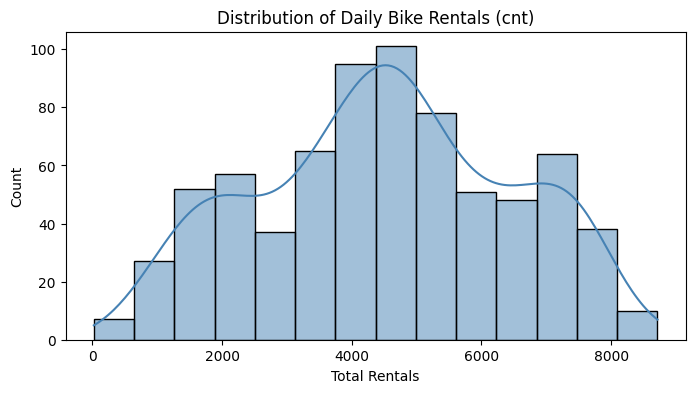

In [134]:
# Distribution of our target variable
plt.figure(figsize=(8, 4))
sns.histplot(df['cnt'], kde=True, color='steelblue')
plt.title('Distribution of Daily Bike Rentals (cnt)')
plt.xlabel('Total Rentals')
plt.show()

The plot is roughly bell shaped and fairly symmetric. Hence target looks well behaved

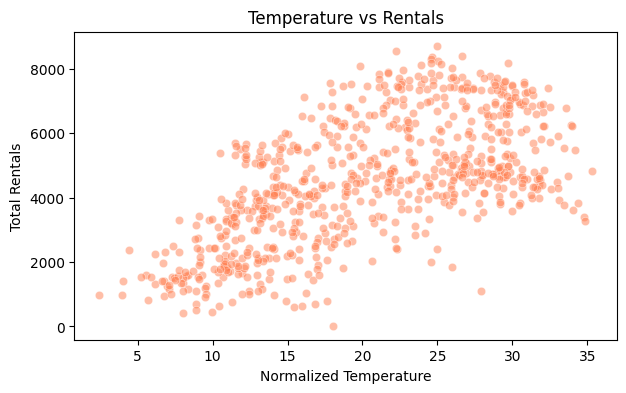

In [135]:
# Temperature vs Rentals
plt.figure(figsize=(7, 4))
sns.scatterplot(x='temp', y='cnt', data=df, alpha=0.5, color='coral')
plt.title('Temperature vs Rentals')
plt.xlabel('Normalized Temperature')
plt.ylabel('Total Rentals')
plt.show()

The plot suggests that tempersature is an important predictor. It looks roughly like an upward sloping band.
That suggests a roughly linear relationship.

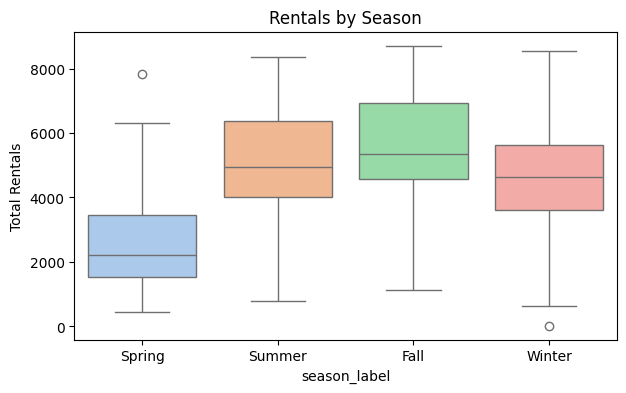

In [136]:
# Rentals by Season
season_map = {1:'Spring', 2:'Summer', 3:'Fall', 4:'Winter'}
df['season_label'] = df['season'].map(season_map)

plt.figure(figsize=(7, 4))
sns.boxplot(
    x='season_label', y='cnt', data=df, order=['Spring','Summer','Fall','Winter'],
    palette='pastel',hue='season_label',)
plt.title('Rentals by Season')
plt.ylabel('Total Rentals')
plt.show()

The initial boxplot showed that bike rentals change significantly depending on the season. This supports the inclusion of season as a categorical predictor in the linear regression mode

In [137]:
# Drop columns that are not useful as features:
# instant: just a row number
# dteday: date (we already have yr, mnth)
# casual + registered: they add up to cnt
# season_label: this was created just for plotting
# atemp : it's almost identical to temp (highly correlated)
# year & yr : to focus on influential factors rather than time-based growth effects

df_model = df.drop(columns=['instant', 'dteday', 'casual', 'registered','atemp','season_label','yr','year'])
print('Columns remaining:', list(df_model.columns))

Columns remaining: ['season', 'mnth', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'hum', 'windspeed', 'cnt', 'day', 'month']


In [138]:
# Renaming variables
df_model['season'] = df_model['season'].map({
    1: 'Spring',
    2: 'Summer',
    3: 'Fall',
    4: 'Winter'
})

df_model['weekday'] = df_model['weekday'].map({
    0: 'Sunday',
    1: 'Monday',
    2: 'Tuesday',
    3: 'Wednesday',
    4: 'Thursday',
    5: 'Friday',
    6: 'Saturday'
})

df_model['season'] = pd.Categorical(
    df_model['season'],
    categories=['Spring', 'Summer', 'Fall', 'Winter'],
    ordered=True
)
df_encoded = pd.get_dummies(df_model, drop_first=True)

In [139]:
# One-hot encoding
categorical_cols = ['season', 'mnth', 'weekday', 'weathersit', 'holiday', 'workingday']

df_encoded = pd.get_dummies(df_model, columns=categorical_cols, drop_first=True)

In [140]:
# Features & target
X = df_encoded.drop(columns=['cnt'])
y = df_encoded['cnt']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print(f'Train: {X_train.shape}, Test: {X_test.shape}')

Train: (584, 29), Test: (146, 29)


In [146]:
#Scaling
from sklearn.preprocessing import StandardScaler

numeric_cols = ['temp', 'hum', 'windspeed']
scaler = StandardScaler()
X[numeric_cols] = scaler.fit_transform(X[numeric_cols])

In [142]:

# Model
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [143]:
# Predict
y_pred = model.predict(X_test)

# Evaluate
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R2:", r2)

RMSE: 1305.7037464669625
R2: 0.5019161593122925


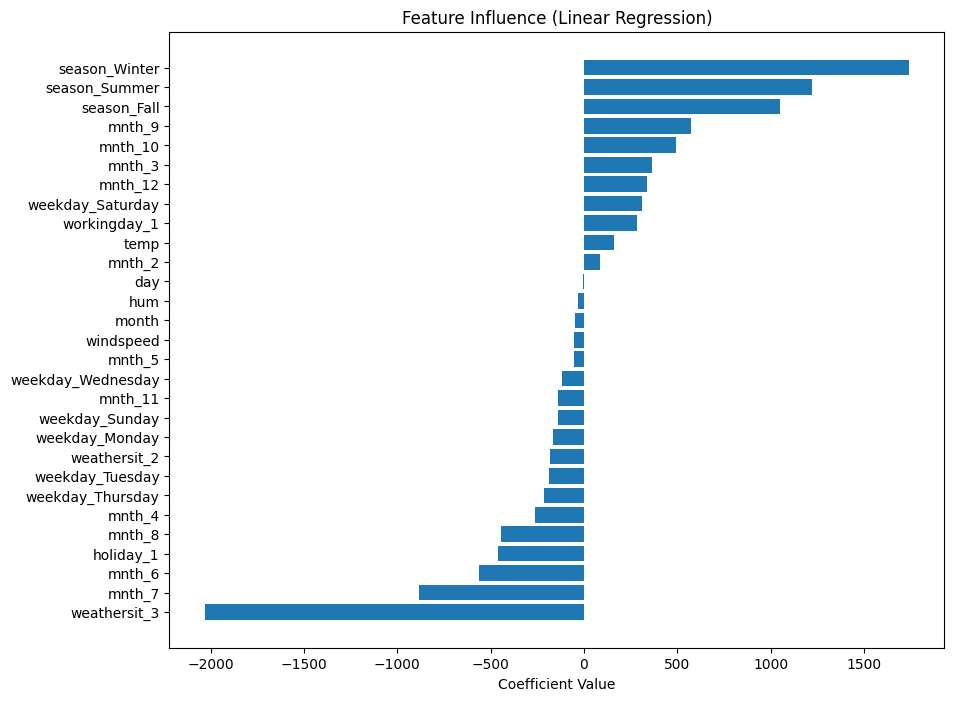

In [147]:
# Feature influence plot
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})
coef_df_sorted = coef_df.sort_values(by="Coefficient", ascending=True)
plt.figure(figsize=(10, 8))
plt.barh(coef_df_sorted["Feature"], coef_df_sorted["Coefficient"])
plt.xlabel("Coefficient Value")
plt.title("Feature Influence (Linear Regression)")
plt.show()

**Analysis**

- R-squared value shows that the model explains thta 50% of variabilty in bike rental demand
- This indicates that seasonal, weather, and calendar factors account for half of the demand variation.
- Certain seasons significantly increase rentals compared to the baseline season.
Winter appears to have the highest positive impact.
- Severe weather conditions drastically  reduce rentals.
This is the strongest behavioral negative factor.
- Rentals increase during favorable seasons and working days. Severe weather and holidays significantly reduce demand.


**Conclusion**

The Multiple Linear Regression model effectively captures the primary drivers of bike-sharing demand. It provides actionable insights that can guide strategic planning, demand management, and targeted marketing initiatives.


Weather conditions emerge as the most influential factor, with adverse weather (rain/light snow) significantly reducing demand. Temperature has a strong positive effect, confirming that warmer days substantially increase ridership. Seasonal analysis reveals that Winter exhibits a stronger adjusted seasonal effect after controlling for weather and environmental variables. Additionally, working days contribute positively to rentals, highlighting the importance of commuter-driven usage.

To improve performance, the company should prioritize weather-responsive strategies, such as targeted promotions during adverse conditions and capacity scaling during warm, clear-weather periods. Strengthening commuter-focused plans and optimizing bike allocation using weather forecasts can further enhance operational efficiency and revenue stability.

